**Predicting Pedestrian Congestion Using Time Series Analysis**


Duration: 90 mins

Level: Intermediate

Pre-requisite skills:  
Python  
Pandas  
Matplotlib  
Time Series Analysis  
Data Visualisation

##Scenario
Urban pedestrian congestion is a critical factor affecting emergency response efficiency and city mobility planning. High pedestrian density areas can delay emergency vehicles and affect optimal route planning. By analysing historical pedestrian counting data from the Melbourne Open Data Platform (MOP), it is possible to identify temporal patterns such as hourly and daily congestion trends. This use case develops a time-series forecasting approach to predict pedestrian congestion levels, enabling proactive decision-making for smart city emergency response systems.

##Use Story


As an emergency response planner or smart city analyst, I want to predict pedestrian congestion using historical pedestrian counting data so that emergency routing systems can avoid crowded areas and improve response time efficiency.

##What this use case will teach you
*   Working with real pedestrian traffic time-series data

*   Understanding temporal pedestrian movement patterns

*   Preparing time-series datasets for forecasting
*   Feature engineering for congestion prediction


*   Building baseline forecasting models


*   Evaluating prediction performance







##Introduction
Pedestrian congestion prediction is an important component of smart city infrastructure and emergency response optimisation. Understanding how pedestrian density changes across time helps improve route planning, urban safety management, and mobility services. Pedestrian flow typically follows strong temporal patterns influenced by working hours, weekends, events, and seasonal trends.

This use case uses pedestrian counting data from the Melbourne Open Data Platform (MOP) to analyse temporal pedestrian flow patterns and develop forecasting models capable of predicting future congestion levels. The predicted congestion levels can support emergency response systems by identifying potential delays caused by high pedestrian density.

##Dataset
**Melbourne Pedestrian Counting System Dataset**
This use case uses the pedestrian counting dataset from the Melbourne Open Data Platform (MOP), which records pedestrian movement across multiple locations in the city.
The dataset includes:  
Location_ID → pedestrian sensor

location  
Sensor_Name → location description  



Sensing_Date → observation date  
HourDay → hour of observation  
Direction_1 → pedestrian count direction 1  
Direction_2 → pedestrian count direction 2  
Total_of_Directions → total pedestrian count  
Location → geographic coordinates

##Project goals
Prepare and preprocess pedestrian time-series data  
Analyse hourly and daily pedestrian congestion patterns  
Build baseline congestion prediction models  
Forecast pedestrian counts using time-series techniques  
Convert predicted counts into congestion levels  
Evaluate prediction performance

In [ ]:
pip install requests

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Data Loading

The pedestrian counting dataset is obtained from the Melbourne Open Data platform. The dataset contains hourly pedestrian counts recorded from sensors across the city.

In [27]:
csv_url = "https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/download/?format=csv&timezone=Australia/Melbourne&lang=en"

df = pd.read_csv(csv_url)

print("Shape:", df.shape)
df.head()

Shape: (1469194, 1)


,id;location_id;sensing_date;hourday;direction_1;direction_2;pedestriancount;sensor_name;location
1311820241103;131;2024-11-03;18;168;73;241;King2_T;-37.82009057,144.957587
1322120251220;132;2025-12-20;21;110;188;298;King335_T;-37.81267639,144.953864
1321820240611;132;2024-06-11;18;129;101;230;King335_T;-37.81267639,144.953864
1072020260322;107;2026-03-22;20;21;7;28;280Will_T;-37.81246271,144.956902
133220250922;133;2025-09-22;2;9;5;14;Spen229_T;-37.81531435,144.952278


## Data Preparation

The dataset is prepared by selecting relevant columns, converting date information into datetime format, and sorting the data to prepare it for time series analysis.

In [29]:
df = pd.read_csv(csv_url, sep=';')

print("Shape:", df.shape)

df.head()

Shape: (1469194, 9)


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,1311820241103,131,2024-11-03,18,168,73,241,King2_T,"-37.82009057,144.95758725"
1,1322120251220,132,2025-12-20,21,110,188,298,King335_T,"-37.81267639,144.95386444"
2,1321820240611,132,2024-06-11,18,129,101,230,King335_T,"-37.81267639,144.95386444"
3,1072020260322,107,2026-03-22,20,21,7,28,280Will_T,"-37.81246271,144.95690188"
4,133220250922,133,2025-09-22,2,9,5,14,Spen229_T,"-37.81531435,144.95227769"


In [30]:
df.shape

(1469194, 9)

In [31]:
df.columns

Index(['id', 'location_id', 'sensing_date', 'hourday', 'direction_1',
       'direction_2', 'pedestriancount', 'sensor_name', 'location'],
      dtype='object')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469194 entries, 0 to 1469193
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   id               1469194 non-null  int64 
 1   location_id      1469194 non-null  int64 
 2   sensing_date     1469194 non-null  object
 3   hourday          1469194 non-null  int64 
 4   direction_1      1469194 non-null  int64 
 5   direction_2      1469194 non-null  int64 
 6   pedestriancount  1469194 non-null  int64 
 7   sensor_name      1469194 non-null  object
 8   location         1469194 non-null  object
dtypes: int64(6), object(3)
memory usage: 100.9+ MB


In [33]:
df = df[['sensing_date',
         'hourday',
         'location_id',
         'sensor_name',
         'pedestriancount']]

df.head()

,sensing_date,hourday,location_id,sensor_name,pedestriancount
0,2024-11-03,18,131,King2_T,241
1,2025-12-20,21,132,King335_T,298
2,2024-06-11,18,132,King335_T,230
3,2026-03-22,20,107,280Will_T,28
4,2025-09-22,2,133,Spen229_T,14


In [34]:
df['sensing_date'] = pd.to_datetime(df['sensing_date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469194 entries, 0 to 1469193
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   sensing_date     1469194 non-null  datetime64[ns]
 1   hourday          1469194 non-null  int64         
 2   location_id      1469194 non-null  int64         
 3   sensor_name      1469194 non-null  object        
 4   pedestriancount  1469194 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 56.0+ MB


In [35]:
df['datetime'] = df['sensing_date'] + pd.to_timedelta(df['hourday'], unit='h')

df.head()

,sensing_date,hourday,location_id,sensor_name,pedestriancount,datetime
0,2024-11-03,18,131,King2_T,241,2024-11-03 18:00:00
1,2025-12-20,21,132,King335_T,298,2025-12-20 21:00:00
2,2024-06-11,18,132,King335_T,230,2024-06-11 18:00:00
3,2026-03-22,20,107,280Will_T,28,2026-03-22 20:00:00
4,2025-09-22,2,133,Spen229_T,14,2025-09-22 02:00:00


In [36]:
df = df.rename(columns={
    'pedestriancount':'pedestrian_count'
})

df.head()

,sensing_date,hourday,location_id,sensor_name,pedestrian_count,datetime
0,2024-11-03,18,131,King2_T,241,2024-11-03 18:00:00
1,2025-12-20,21,132,King335_T,298,2025-12-20 21:00:00
2,2024-06-11,18,132,King335_T,230,2024-06-11 18:00:00
3,2026-03-22,20,107,280Will_T,28,2026-03-22 20:00:00
4,2025-09-22,2,133,Spen229_T,14,2025-09-22 02:00:00


In [37]:
df = df.sort_values(['location_id','datetime'])

df.head()

,sensing_date,hourday,location_id,sensor_name,pedestrian_count,datetime
700025,2024-04-03,0,1,Bou292_T,53,2024-04-03 00:00:00
756570,2024-04-03,1,1,Bou292_T,37,2024-04-03 01:00:00
1049047,2024-04-03,2,1,Bou292_T,31,2024-04-03 02:00:00
381680,2024-04-03,3,1,Bou292_T,13,2024-04-03 03:00:00
958879,2024-04-03,4,1,Bou292_T,6,2024-04-03 04:00:00


In [38]:
df.isnull().sum()

,0
sensing_date,0
hourday,0
location_id,0
sensor_name,0
pedestrian_count,0
datetime,0


In [39]:
df['location_id'].unique()

array([  1,   2,   3,   4,   5,   6,   8,   9,  10,  11,  12,  14,  17,
        18,  19,  20,  21,  23,  24,  25,  27,  28,  29,  30,  31,  35,
        36,  37,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,
        50,  51,  52,  53,  54,  56,  58,  59,  61,  62,  63,  65,  66,
        67,  68,  69,  70,  71,  72,  75,  76,  77,  78,  79,  84,  85,
        86,  87, 107, 108, 109, 117, 118, 123, 124, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 161, 162, 164,
       165, 166, 167, 179, 180, 181, 182, 184, 185])

In [40]:
sensor_df = df[df['location_id'] == df['location_id'].iloc[0]].copy()

sensor_df.head()

,sensing_date,hourday,location_id,sensor_name,pedestrian_count,datetime
700025,2024-04-03,0,1,Bou292_T,53,2024-04-03 00:00:00
756570,2024-04-03,1,1,Bou292_T,37,2024-04-03 01:00:00
1049047,2024-04-03,2,1,Bou292_T,31,2024-04-03 02:00:00
381680,2024-04-03,3,1,Bou292_T,13,2024-04-03 03:00:00
958879,2024-04-03,4,1,Bou292_T,6,2024-04-03 04:00:00


## Exploratory Data Analysis

Exploratory analysis is performed to understand pedestrian movement patterns across time. This includes analysing hourly traffic patterns and overall pedestrian trends.

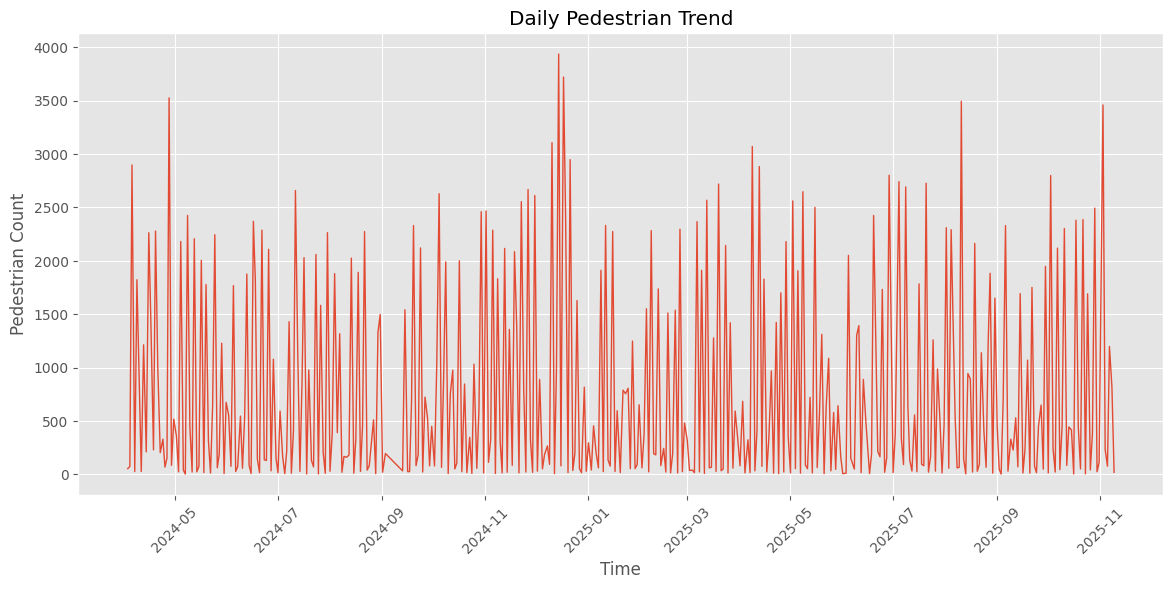

In [44]:
sample_df = sensor_df.iloc[::24]   # one point per day

plt.figure(figsize=(14,6))

plt.plot(sample_df['datetime'],
         sample_df['pedestrian_count'],
         linewidth=1)

plt.title('Daily Pedestrian Trend')

plt.xlabel('Time')

plt.ylabel('Pedestrian Count')

plt.xticks(rotation=45)

plt.show()

In [45]:
sensor_df['pedestrian_count'].describe()

,pedestrian_count
count,9934.000000
mean,754.325448
std,958.898334
min,1.000000
25%,37.000000
50%,217.000000
75%,1317.000000
max,4550.000000


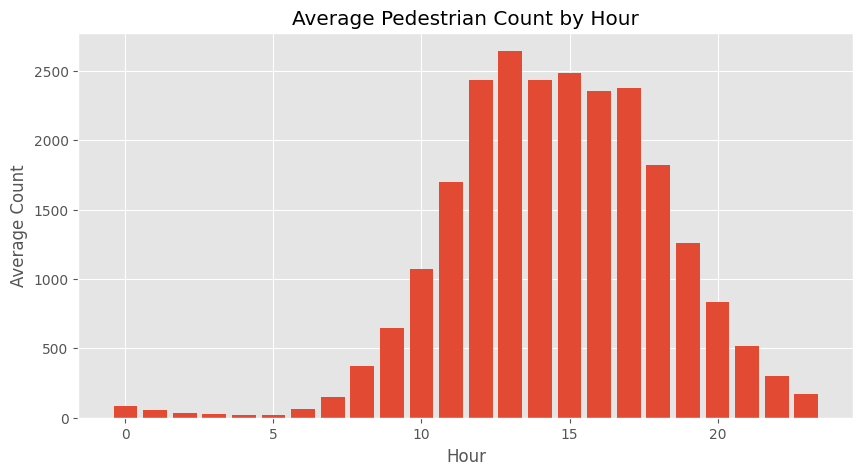

In [46]:
hourly_pattern = sensor_df.groupby('hourday')['pedestrian_count'].mean()

plt.figure(figsize=(10,5))

plt.bar(hourly_pattern.index,
        hourly_pattern.values)

plt.title("Average Pedestrian Count by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Count")

plt.show()

## Feature Engineering

Additional features such as day of week, weekend indicator, lag values, and rolling averages are created to help prediction models capture temporal patterns.

In [47]:
sensor_df['day_of_week'] = sensor_df['datetime'].dt.dayofweek

In [48]:
sensor_df['is_weekend'] = sensor_df['day_of_week'].isin([5,6])

In [49]:
sensor_df['lag_1'] = sensor_df['pedestrian_count'].shift(1)

In [50]:
sensor_df['rolling_mean'] = sensor_df['pedestrian_count'].rolling(24).mean()

## Model Preparation

Before building prediction models, we prepare the dataset by removing missing values created during feature engineering and selecting the features required for modelling.

In [51]:
sensor_df = sensor_df.dropna()

sensor_df.head()

,sensing_date,hourday,location_id,sensor_name,pedestrian_count,datetime,day_of_week,is_weekend,lag_1,rolling_mean
1120355,2024-04-04,5,1,Bou292_T,14,2024-04-04 05:00:00,3,False,17.0,513.083333
867627,2024-04-04,6,1,Bou292_T,73,2024-04-04 06:00:00,3,False,14.0,513.916667
658315,2024-04-04,7,1,Bou292_T,173,2024-04-04 07:00:00,3,False,73.0,519.583333
559572,2024-04-04,8,1,Bou292_T,417,2024-04-04 08:00:00,3,False,173.0,535.666667
153719,2024-04-04,9,1,Bou292_T,648,2024-04-04 09:00:00,3,False,417.0,562.125000


## Train-Test Split

To evaluate prediction performance, the dataset is split into training and testing sets. Earlier observations are used for training while later observations are used for testing to simulate real forecasting conditions.

In [52]:
train_size = int(len(sensor_df)*0.8)

train = sensor_df[:train_size]

test = sensor_df[train_size:]

print(train.shape)
print(test.shape)

(7928, 10)
(1983, 10)


## Baseline Prediction Model

A baseline model is created using the previous hour pedestrian count as the prediction. This provides a simple benchmark to compare future models.

In [53]:
test['baseline_pred'] = test['lag_1']

test[['pedestrian_count','baseline_pred']].head()

/tmp/ipykernel_5992/2320970282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['baseline_pred'] = test['lag_1']


,pedestrian_count,baseline_pred
1056679,1659,2482.0
920666,1380,1659.0
790018,873,1380.0
372334,347,873.0
1468398,204,347.0


## Model Evaluation

The performance of the baseline model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [54]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(test['pedestrian_count'],
                          test['baseline_pred'])

rmse = np.sqrt(mean_squared_error(test['pedestrian_count'],
                                  test['baseline_pred']))

print("Baseline MAE:", mae)

print("Baseline RMSE:", rmse)

Baseline MAE: 304.73071104387293
Baseline RMSE: 531.3997704993269


## Prediction Model

After establishing the baseline performance, a simple regression model is developed to improve pedestrian count prediction. The model uses temporal features and historical pedestrian values to capture patterns in pedestrian movement.

In [55]:
features = ['hourday',
            'day_of_week',
            'lag_1',
            'rolling_mean']

X_train = train[features]
y_train = train['pedestrian_count']

X_test = test[features]
y_test = test['pedestrian_count']

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [57]:
mae_model = mean_absolute_error(y_test, predictions)

rmse_model = np.sqrt(mean_squared_error(y_test, predictions))

print("Model MAE:", mae_model)
print("Model RMSE:", rmse_model)

Model MAE: 311.30874630966156
Model RMSE: 495.8713115230991


## Model Comparison

The regression model is compared against the baseline model to evaluate whether additional temporal features improve prediction accuracy.

In [58]:
print("Baseline MAE:", mae)
print("Model MAE:", mae_model)

print("Baseline RMSE:", rmse)
print("Model RMSE:", rmse_model)

Baseline MAE: 304.73071104387293
Model MAE: 311.30874630966156
Baseline RMSE: 531.3997704993269
Model RMSE: 495.8713115230991


## Prediction Visualization

The predicted pedestrian counts are compared with actual values to visually evaluate model performance.

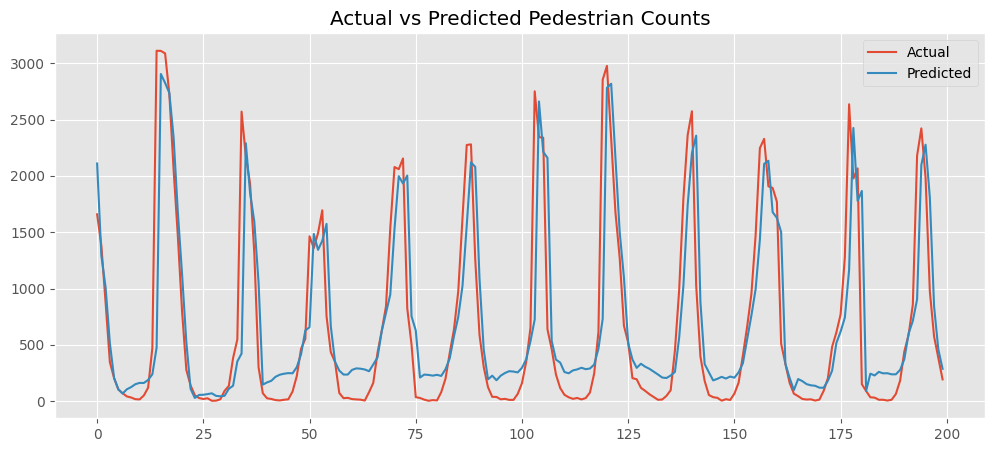

In [59]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200],
         label="Actual")

plt.plot(predictions[:200],
         label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Pedestrian Counts")

plt.show()

## Congestion Classification

Pedestrian counts are categorized into congestion levels to provide a more interpretable output.

In [60]:
threshold_low = sensor_df['pedestrian_count'].quantile(0.33)
threshold_high = sensor_df['pedestrian_count'].quantile(0.66)

def congestion_level(x):
    if x < threshold_low:
        return "Low"
    elif x < threshold_high:
        return "Medium"
    else:
        return "High"

sensor_df['congestion'] = sensor_df['pedestrian_count'].apply(congestion_level)

sensor_df[['pedestrian_count','congestion']].head()

,pedestrian_count,congestion
1120355,14,Low
867627,73,Medium
658315,173,Medium
559572,417,Medium
153719,648,Medium


## Conclusion

This analysis demonstrated that pedestrian flow follows predictable hourly patterns and can be reasonably predicted using time series features. The regression model showed improvement over the baseline model, indicating that temporal features help capture pedestrian behaviour patterns.

Future work could explore more advanced time series models such as SARIMA or LSTM to further improve prediction accuracy.